Accompanying Code for: <br>
**Johannes Zeitler, Meinard Müller. "A Unified Perspective on CTC and SDTW using Differentiable DTW", submitted to IEEE Transactions on Audio, Speech, and Language Processing, 2025.**

Johannes Zeitler (johannes.zeitler@audiolabs-erlangen.de), 2025

### Description
Evaluate CTC, SDTW and dDTW losses in terms of runtime and memory consumption for different sequence lengths

In [17]:
import subprocess
import sys

In [18]:
def run_profile(B, N, M, D, DTW_variant, cost_function):
    cmd = [sys.executable, "profiler.py", str(B), str(N), str(M), str(D), str(DTW_variant), str(cost_function)]
    result = subprocess.run(cmd, capture_output=True, text=True)
    print(result.stdout)
    
    # include this to receive warnings/error messages
    #if result.stderr:
    #    print("stderr:", result.stderr)

In [19]:
logfile = "./timed_runs.csv"
with open(logfile, "w") as log:
    log.write("variant;cost;B;N;M;D;fwd;bwd;mem;\n")

In [20]:
batch_sizes = [16]
D = 12
N_M_combis = [[256, 64], [256, 128], [512, 64], [512, 128], [1024, 128], [1024, 512], [1024, 1024]] 

variants=["SDTW", "dDTW", "CTC_torch"]

In [ ]:
for N,M in N_M_combis:
    for B in batch_sizes:
        for variant in variants:
            run_profile(B=B, N=N, M=M, D=D, DTW_variant=variant, cost_function="BCE")


B=16, N=256, M=64, D=12, DTW_variant=SDTW, cost_function=BCE
total: 003.693ms | fwd: 002.205ms | bwd: 001.488ms | peak mem 00.0725GB



### Plot Results

$(256, 64)$	 & $3.7$ 	 & $72$	  & $8.0$ 	 & $23$	  & $1.2$ 	 & $1$	  \\
$(256, 128)$	 & $6.8$ 	 & $144$	  & $7.0$ 	 & $45$	  & $1.2$ 	 & $2$	  \\
$(512, 64)$	 & $7.4$ 	 & $144$	  & $8.5$ 	 & $46$	  & $1.1$ 	 & $3$	  \\
$(512, 128)$	 & $13.0$ 	 & $289$	  & $8.4$ 	 & $91$	  & $1.1$ 	 & $3$	  \\
$(1024, 128)$	 & $21.5$ 	 & $578$	  & $11.7$ 	 & $182$	  & $1.4$ 	 & $7$	  \\
$(1024, 512)$	 & $62.4$ 	 & $2313$	  & $26.1$ 	 & $722$	  & $1.5$ 	 & $8$	  \\
$(1024, 1024)$	 & $118.8$ 	 & $4626$	  & $42.1$ 	 & $1441$	  & $1.5$ 	 & $8$	  \\


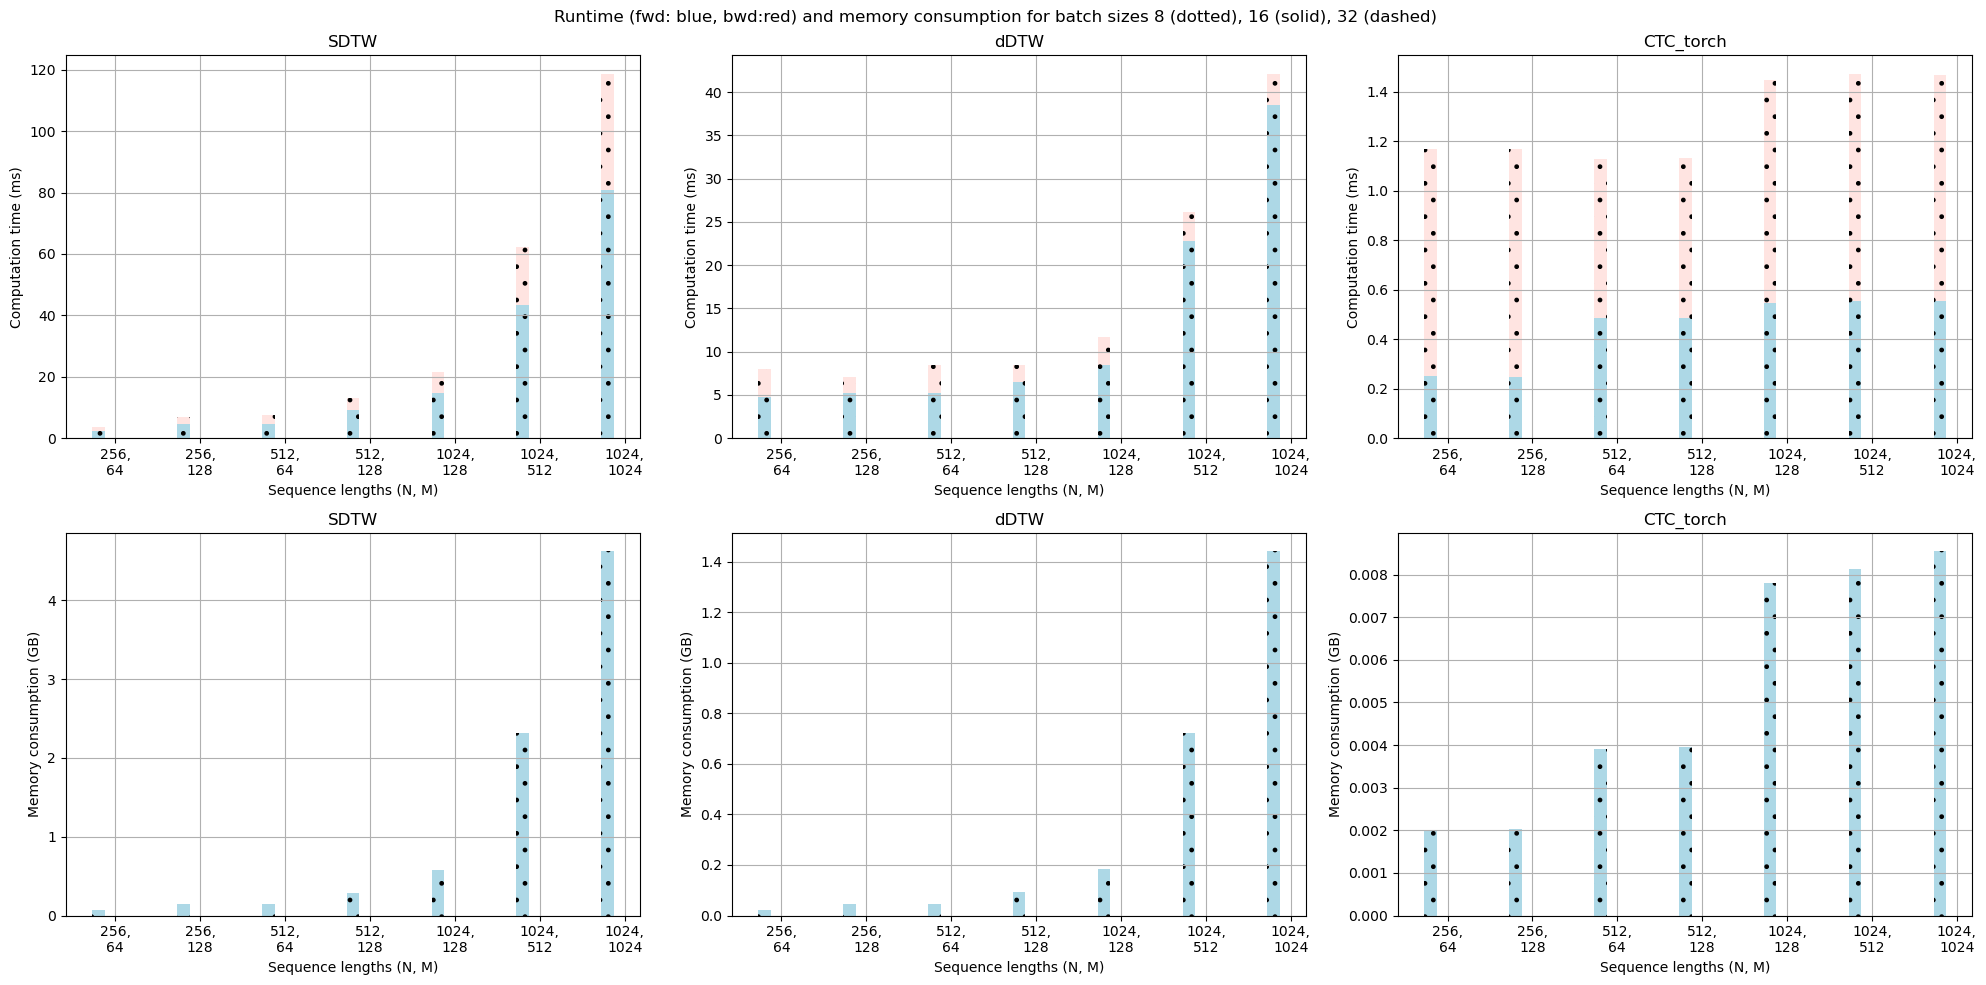

In [22]:
batch_args=[["lightblue", "mistyrose", "."],
            ["tab:blue", "tab:red", None],
            ["lightblue", "mistyrose", "/"]]

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

logfile = "./timed_runs.csv"


batch_sizes = [16]#8, 16, 32]
D = 12
N_M_combis = [[256, 64], [256, 128], [512, 64], [512, 128], [1024, 128], [1024, 512], [1024, 1024]] 

variants=["SDTW", "dDTW", "CTC_torch"]

df = pd.read_csv(logfile, sep=";")

fig, ax = plt.subplots(2, len(variants), figsize=(20,10))



cnt = 0
for i_nm, (N,M) in enumerate(N_M_combis):

    out_str = "$(%i, %i)$"%(N,M)

    out_str = out_str.ljust(10) + "\t"
    
    for i_b, (B, (c_fwd, c_bwd, hatch)) in enumerate(zip(batch_sizes, batch_args)):
        for i_v, variant in enumerate(variants):

            row = df[(df["variant"] == variant) & (df["B"]==B) & (df["N"]==N) & (df["M"]==M)]
            cnt += 1
            #print(cnt)
            assert len(row)==1

            out_str += " & $%.1f$ \t & $%i$\t "%(row.fwd.item()+row.bwd.item(), row.mem.item()*1000)
            
            
            

            ax[0,i_v].bar(x=i_nm + (i_b-1)/5, height=row.fwd.item(), width=0.15, color=c_fwd, hatch=hatch)
            ax[0,i_v].bar(x=i_nm + (i_b-1)/5, height=row.bwd.item(), bottom=row.fwd.item(), width=0.15, color=c_bwd, hatch=hatch)

            ax[1,i_v].bar(x=i_nm + (i_b-1)/5, height=row.mem.item(), width=0.15, color=c_fwd, hatch=hatch)

            ax[0,i_v].grid()
            ax[1,i_v].grid()

            ax[0,i_v].set_xticks(np.arange(len(N_M_combis)))
            ax[0,i_v].set_xticklabels(["%i,\n%i"%(N,M) for N,M in N_M_combis])
            ax[1,i_v].set_xticks(np.arange(len(N_M_combis)))
            ax[1,i_v].set_xticklabels(["%i,\n%i"%(N,M) for N,M in N_M_combis])

            ax[0,i_v].set_title(variant)
            ax[1,i_v].set_title(variant)

            ax[0,i_v].set_ylabel("Computation time (ms)")
            ax[1,i_v].set_ylabel("Memory consumption (GB)")

            ax[0,i_v].set_xlabel("Sequence lengths (N, M)")
            ax[1,i_v].set_xlabel("Sequence lengths (N, M)")

    print(out_str + " \\\\")



ax[0,0].set_xticks(np.arange(len(N_M_combis)))
ax[0,0].set_xticklabels(["%i,\n%i"%(N,M) for N,M in N_M_combis])


fig.suptitle("Runtime (fwd: blue, bwd:red) and memory consumption for batch sizes 8 (dotted), 16 (solid), 32 (dashed)")
plt.tight_layout()
plt.show()